<style>
  .banner-trabajo {
    font-family: 'Georgia', 'Times New Roman', Times, serif;
    width: 80%;
    margin: 20px auto;
    padding: 10px 20px 20px 20px;
    background: #ffffff;
    border-left: 20px solid #003366;
    box-shadow: 0 5px 20px rgba(0,0,0,0.1);
    text-align: center;
    border-radius: 8px;
  }
  .banner-trabajo .encabezado {
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 20px;
    margin-bottom: 15px;
    padding-bottom: 1px;
    border-bottom: 2px solid #eeeeee;
  }
  .banner-trabajo .logo-universidad {
    max-width: 80px;
    height: auto;
  }
  .banner-trabajo .universidad {
    font-size: 1.1em;
    color: #003366;
    font-weight: bold;
    text-align: left;
  }
  .banner-trabajo h1 {
    color: #003366;
    font-size: 2.2em;
    margin: 0.6em 0;
    font-weight: bold;
    line-height: 1.2;
  }
  .banner-trabajo h2 {
    color: #444444;
    font-size: 1.4em;
    margin-bottom: 0.8em;
    font-weight: normal;
    font-style: italic;
  }
  .banner-trabajo .info-autor {
    margin-bottom: 0em;
    font-size: 1.1em;
    color: #222222;
  }
  .banner-trabajo .fecha {
    margin: 1.0em 0 1.0em 0;
    padding: 0.8em 0;
    color: #666666;
    font-size: 1em;
  }
</style>

<div class="banner-trabajo">
  <div class="encabezado">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" class="logo-universidad">
    <div class="universidad"> Universidad Nacional de Colombia</div>
  </div>
  
  <h1>Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2>Entrenamiento de Red Neuronal Convolucional (CNN) con datos de fríjol</h2>
  
  <div class="info-autor">
    <p><strong>Autor:</strong> Selene Solano Vera</p>
  </div>
  
  <div class="fecha">Medellín, Febrero de 2026</div>

  <div style="height: 0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de librerías necesarias para el entrenamiento de una Red Neuronal Convolucional (Convolutional Neural Network - CNN) con TensorFlow/Keras para la clasificación de imágenes multiespectrales de plantas de frijol.

In [35]:
# TensorFlow y Keras para construcción de redes neuronales convolucionales
import tensorflow as tf                           
from tensorflow.keras import datasets, layers, models 

import pathlib                                    
import os                                         
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt                   

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score, cohen_kappa_score, ConfusionMatrixDisplay

# 1. Carga de Datos

Esta sección carga y prepara las imágenes multiespectrales de plantas de frijol para el entrenamiento del modelo.

## 1.1. Configuración de parámetros de carga

Se definen los hiperparámetros fundamentales para el procesamiento de imágenes:
- **Tamaño de imagen**: Redimensionamiento estándar para consistencia del modelo
- **Batch size**: Número de imágenes procesadas simultáneamente

In [ ]:
# Configuración de hiperparámetros para carga de imágenes
batch_size = 32        
img_height = 180       
img_width = 180        

In [31]:
# Directorio que contiene las imágenes organizadas por clases (tratamientos)
data_dir = "extracted_objects_frijol"

# Creación del dataset de entrenamiento (80% de los datos)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale')

Found 3830 files belonging to 4 classes.
Using 3064 files for training.


In [32]:
# Creación del dataset de validación (20% de los datos)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale')

Found 3830 files belonging to 4 classes.
Using 766 files for validation.


In [33]:
# Extracción de nombres de clases desde la estructura de directorios
class_names = train_ds.class_names
print(class_names)

['T1', 'T2', 'T3', 'T4']


## 1.2. Visualización exploratoria de los datos

Inspección visual de muestras del dataset para verificar la correcta carga de imágenes y la calidad de los datos.

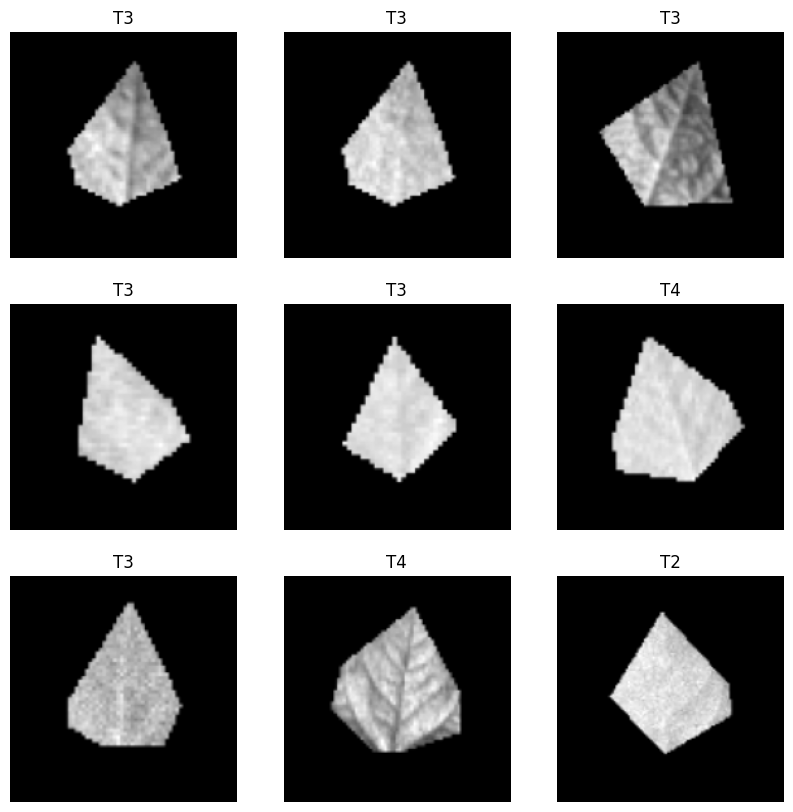

In [ ]:
# Visualización de 9 imágenes de muestra del conjunto de entrenamiento
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   # Toma un batch
  for i in range(9):                      # Muestra primeras 9 imágenes
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")  # Visualización en escala de grises
    plt.title(class_names[labels[i]])     # Título con la clase correspondiente
    plt.axis("off")                       

In [ ]:
# Verificación de las dimensiones de los batches
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)   # (batch_size, height, width, channels)
  print(labels_batch.shape)  # (batch_size,)
  break                      # Solo muestra el primer batch

(32, 180, 180, 1)
(32,)


# 2. Construcción del Modelo CNN

**Componentes de la CNN:**
1. **Capas Convolucionales (Conv2D)**: Aplican filtros para detectar características locales
2. **Capas de Pooling (MaxPooling2D)**: Reducen dimensionalidad preservando información relevante
3. **Capa de Aplanamiento (Flatten)**: Convierte matriz 2D en vector 1D
4. **Capas Densas (Dense)**: Clasificación final basada en características extraídas

## 2.1. Optimización del pipeline de datos

Se configuran técnicas de optimización para maximizar la eficiencia del entrenamiento:
- **Caching**: Mantiene datos en memoria después de la primera época
- **Prefetching**: Prepara el siguiente batch mientras se procesa el actual

In [17]:
# Configuración automática de buffer de prefetching
AUTOTUNE = tf.data.AUTOTUNE  # TensorFlow ajusta dinámicamente el tamaño del buffer

# Aplicación de optimizaciones al conjunto de entrenamiento
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)  # Cache + Prefetch para eficiencia

# Aplicación de optimizaciones al conjunto de validación
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 2.2. Definición de la arquitectura CNN

Se construye una CNN secuencial con tres bloques convolucionales seguidos de capas densas para clasificación.

In [18]:
# Definición del número de clases de salida
num_classes = 4  # Cuatro tratamientos de deficiencia de fósforo

# Construcción de la arquitectura CNN secuencial
model = tf.keras.Sequential([
  # Capa de normalización: escala píxeles de [0, 255] a [0, 1]
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 1)),
  
  # Primer bloque convolucional
  tf.keras.layers.Conv2D(32, 3, activation='relu'),  # 32 filtros 3×3 con activación ReLU
  tf.keras.layers.MaxPooling2D(),                    # Pooling 2×2 para reducción espacial
  
  # Segundo bloque convolucional
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  
  # Tercer bloque convolucional
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  
  # Aplanamiento de matriz 2D a vector 1D
  tf.keras.layers.Flatten(),
  
  # Capa densa de clasificación con 128 neuronas
  tf.keras.layers.Dense(128, activation='relu'),
  
  # Capa de salida con 4 neuronas (una por clase)
  tf.keras.layers.Dense(num_classes)  # Sin activación (logits para SparseCategoricalCrossentropy)
])

d:\1. Biblioteca Usuario\Documents\UNAL\MAESTRÍA\TESIS\disease-detection-multispectral-images\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Visualización de la arquitectura del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,657,860 (6.32 MB)

 Trainable params: 1,657,860 (6.32 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compilación del modelo con optimizador, función de pérdida y métricas
model.compile(
  optimizer='adam',  # Adam: optimizador adaptativo con momentum
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),  # Para clasificación multiclase con logits
  metrics=['accuracy'])  # Métrica de evaluación: exactitud de clasificación

# 3. Entrenamiento del modelo

In [ ]:
# Entrenamiento del modelo con validación
history = model.fit(
  train_ds,               # Dataset de entrenamiento con imágenes y etiquetas
  validation_data=val_ds, # Dataset de validación para monitorear sobreajuste
  epochs=10               # Número de pasadas completas sobre el conjunto de entrenamiento
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 308ms/step - accuracy: 0.4334 - loss: 1.2074 - val_accuracy: 0.6384 - val_loss: 0.8853
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.7500 - loss: 0.6233 - val_accuracy: 0.9543 - val_loss: 0.2111
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.9726 - loss: 0.1014 - val_accuracy: 0.9922 - val_loss: 0.0374
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.9997 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 1.0000 - loss: 6.4642e-04 - val_accuracy: 1.0000 - val_loss: 9.8947e-04
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 1.0000 - loss: 3.9826e-04 - val_accuracy: 1.0000 - val_loss: 8.0182e-04
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 1.0000 - loss: 2

# 4. Evaluación del Modelo

Esta sección analiza el rendimiento del modelo entrenado mediante:
- **Curvas de aprendizaje**: Evolución de accuracy y loss durante el entrenamiento
- **Métricas de clasificación**: Precisión, Recall, F1-Score por clase
- **Matrices de confusión**: Visualización de aciertos y errores de clasificación

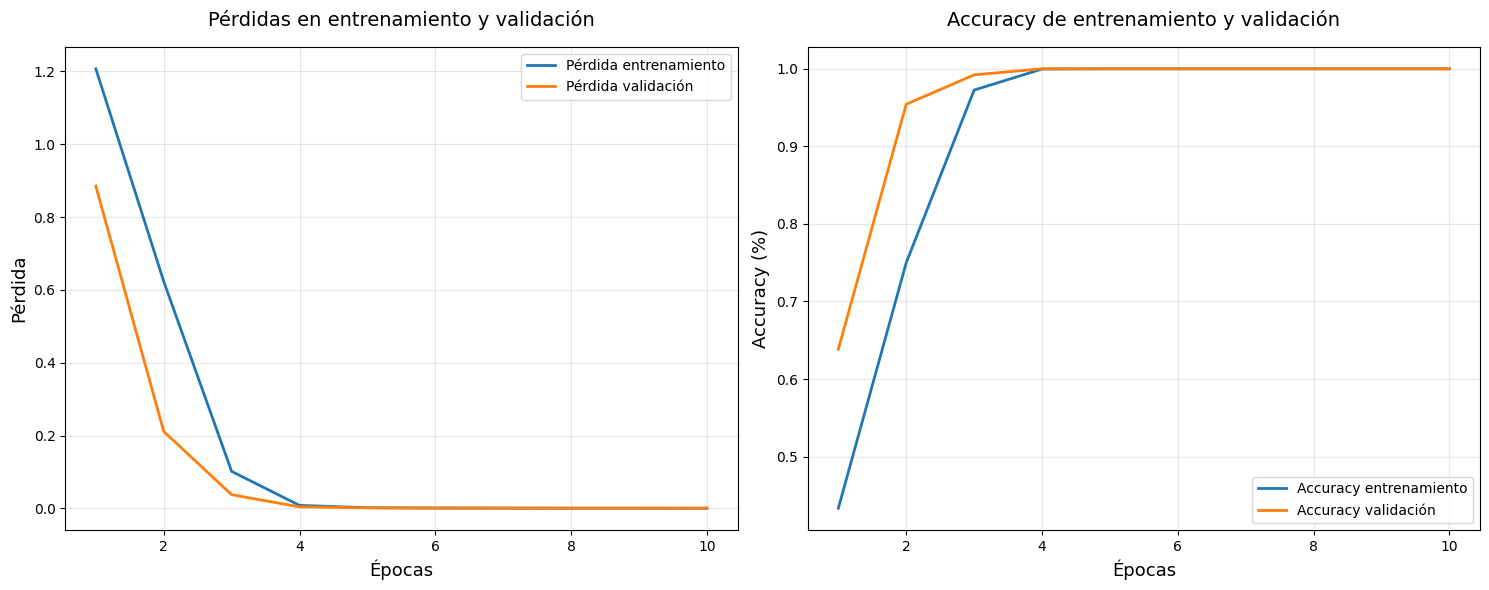

In [24]:
# Carga del historial de entrenamiento desde archivo CSV
history_data = pd.read_csv("results/training_history_frijol_cnn.csv")

# Extracción de épocas para el eje X
epochs = history_data['epoch']

# Creación de visualización de métricas de entrenamiento
plt.figure(figsize=(15, 6))

# Gráfico de evolución de la pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, history_data['loss'], label='Pérdida entrenamiento', linewidth=2, color='#1f77b4')
plt.plot(epochs, history_data['val_loss'], label='Pérdida validación', linewidth=2, color='#ff7f0e')
plt.title('Pérdidas en entrenamiento y validación', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=13)
plt.ylabel('Pérdida', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de evolución de la exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, history_data['accuracy'], label='Accuracy entrenamiento', linewidth=2, color='#1f77b4')
plt.plot(epochs, history_data['val_accuracy'], label='Accuracy validación', linewidth=2, color='#ff7f0e')
plt.title('Accuracy de entrenamiento y validación', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Guardar modelo

In [ ]:
# Persistencia del modelo entrenado en formato Keras
model.save("models/frijol_model_cnn.keras")
print("Model saved successfully as 'frijol_model_cnn.keras'")

Model saved successfully as 'frijol_model_cnn.keras'


## 5. Análisis Detallado de Resultados

Se carga el modelo entrenado y se generan métricas exhaustivas de rendimiento para evaluar su capacidad de generalización.

In [ ]:
# Carga del modelo CNN entrenado desde archivo
trained_model = tf.keras.models.load_model('models/frijol/frijol_model_cnn.keras')

In [ ]:
# Obtener etiquetas reales y predicciones del conjunto de validación (Test)
y_test_true = []
y_test_pred = []

print("Realizando predicciones sobre el conjunto de validación (Test)...")
for images, labels in val_ds:
    preds = trained_model.predict(images, verbose=0)
    y_test_true.extend(labels.numpy())
    y_test_pred.extend(np.argmax(preds, axis=1))

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)

# Generación de predicciones para el conjunto de entrenamiento
y_train_true = []
y_train_pred = []

print("Realizando predicciones sobre el conjunto de entrenamiento...")
for images, labels in train_ds:
    preds = trained_model.predict(images, verbose=0)
    y_train_true.extend(labels.numpy())
    y_train_pred.extend(np.argmax(preds, axis=1))

y_train_true = np.array(y_train_true)
y_train_pred = np.array(y_train_pred)

Realizando predicciones sobre el conjunto de validación (Test)...
Realizando predicciones sobre el conjunto de entrenamiento...


In [ ]:
# Métricas del conjunto de Test
accuracy = accuracy_score(y_test_true, y_test_pred)
precision = precision_score(y_test_true, y_test_pred, average='weighted')
f1 = f1_score(y_test_true, y_test_pred, average='weighted')
kappa = cohen_kappa_score(y_test_true, y_test_pred)

# Métricas del conjunto de Train
train_accuracy = accuracy_score(y_train_true, y_train_pred)
train_precision = precision_score(y_train_true, y_train_pred, average='weighted')
train_f1 = f1_score(y_train_true, y_train_pred, average='weighted')
train_kappa = cohen_kappa_score(y_train_true, y_train_pred)

# Presentación comparativa de resultados
print("-" * 65)
print(f"{'Métrica':<20} | {'Train':<20} | {'Test':<20}")
print("-" * 65)
print(f"{'Accuracy':<20} | {train_accuracy:<20.4f} | {accuracy:<20.4f}")
print(f"{'Precision':<20} | {train_precision:<20.4f} | {precision:<20.4f}")
print(f"{'F1-Score':<20} | {train_f1:<20.4f} | {f1:<20.4f}")
print(f"{'Kappa Score':<20} | {train_kappa:<20.4f} | {kappa:<20.4f}")
print("-" * 65)

-----------------------------------------------------------------
Métrica              | Train                | Test                
-----------------------------------------------------------------
Accuracy             | 1.0000               | 1.0000              
Precision            | 1.0000               | 1.0000              
F1-Score             | 1.0000               | 1.0000              
Kappa Score          | 1.0000               | 1.0000              
-----------------------------------------------------------------


In [ ]:
# Reporte de Clasificación
print("\nReporte de Clasificación (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

print("\nReporte de Clasificación (Train):")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))


Reporte de Clasificación (Test):
              precision    recall  f1-score   support

          T1       1.00      1.00      1.00       194
          T2       1.00      1.00      1.00       182
          T3       1.00      1.00      1.00       201
          T4       1.00      1.00      1.00       189

    accuracy                           1.00       766
   macro avg       1.00      1.00      1.00       766
weighted avg       1.00      1.00      1.00       766


Reporte de Clasificación (Train):
              precision    recall  f1-score   support

          T1       1.00      1.00      1.00       766
          T2       1.00      1.00      1.00       778
          T3       1.00      1.00      1.00       759
          T4       1.00      1.00      1.00       761

    accuracy                           1.00      3064
   macro avg       1.00      1.00      1.00      3064
weighted avg       1.00      1.00      1.00      3064



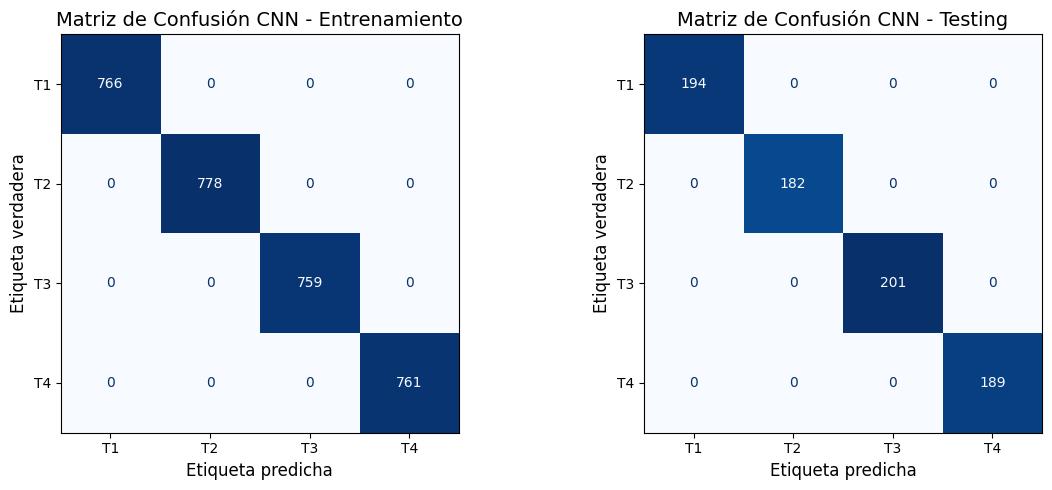

In [ ]:
# Visualización comparativa de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de confusión para conjunto de entrenamiento
cm_train = confusion_matrix(y_train_true, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión CNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de confusión para conjunto de prueba
cm_test = confusion_matrix(y_test_true, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión CNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()